# 1: Problem and Population
I decided to focus on the issue of food waste which relates to topic 12 of the UN SDG’s, responsible consumption and production. It also connects to topic 2 which is zero hunger. It affects the group of people that struggles to pay for their food consumption, such as homeless people, low-income households and college students, as more knowledge about the issue and a better network could form connections that minimize waste and improve people with hunger all at once.
I believe that the topic is missing certain regulations, such as strict rules for restaurants or grocery stores. Additionally, better education about different labels, for example “best by” or “sell by” could improve the situation in private households. The correct discarding of trash is also important, so people need to choose the right trash cans.
Since M1 I further specified the groups of people affected and added correct discarding to the list of possible improvements and points where AI can help.


# 2: Proposed System

*   Input: Either complaint or question. Eg. someone could upload a picture of a dumpster behind a restaurant to file a claim of inproper waste management. Another person could upload a picture or describe a food item with a specific date label and ask about the edibility of this product and how much grace period there is after the date.

*   AI Process: The AI would either evaluate the picture in terms of edibility/amount/kind of items in order to determine if the complaint is valid and then start an official complaint process, asking for details to determine if a business or private household is accused. The complaint will then be forwarded to the specific department.
Otherwise the AI will answer the question by analyzing if it is about waste disposal/expiration date/giving away food. For the examples above, AI would forward an official complaint for case one and answer the expiration date question by giving a specific time estimate for example two.

*   Output: AI will output a summary of the reported complaint and contact details for the specific department or it will provide an answer specialized for each food item and clearly state where to dispose it, when to eat it or where to give it.

*   Real-World Action: Regulations will be inforced strictly following the complaint and people asking questions can implement the newly won knowledge in their behavior and habits to minimize waste and tackle hunger at the same time. (maybe business would learn about apps like "Too Good To Go" to eliminate unnecessary waste).



# 3: Project Code

In [ ]:
!pip install -q google-generativeai

1: Setup

In [ ]:
import google.generativeai as genai
from google.colab import userdata
import json
import time

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
print("Gemini initialized successfully.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Gemini initialized successfully.


2: Setup

In [ ]:
schema_prompt = """
Analyze the user's text input AND any provided image to determine if it is a complaint or a question related to food waste.
If an image is provided, use it to infer details such as waste_type, urgency, food_item, or date_label, supplementing or overriding text descriptions where clear.
Return ONLY valid JSON with exactly these fields:
{
  "request_type": "complaint" or "question",
  "complaint_info": {
    "location": string (the street address or location described, null if request_type is 'question'),
    "waste_type": string (the type of items or problem described, inferred from image if available, null if request_type is 'question'),
    "urgency": "LOW" or "MEDIUM" or "HIGH" (inferred from image if available, null if request_type is 'question'),
    "department": string (which San Jose city department should respond: e.g. "Environmental Services", "Public Works", "Code Enforcement", "Parks & Recreation", null if request_type is 'question'),
    "complaint_description": string (a detailed description of the complaint, including any evidence type like "picture" or "text description", derived from text and image, null if request_type is 'question'),
    "accused_entity_type": "business" or "private household" or "unknown" (null if request_type is 'question')
  },
  "question_info": {
    "question_category": "waste disposal" or "expiration date" or "edibility" or "giving away food" or "other" (null if request_type is 'complaint'),
    "food_item": string (the food item in question, inferred from image if available, null if request_type is 'complaint' or not applicable to the question),
    "date_label": string (the date label on the food item, inferred from image if available, null if request_type is 'complaint' or not applicable to the question),
    "question_text": string (the detailed question asked by the resident, derived from text and image, null if request_type is 'complaint')
  },
  "resident_language": string (language the resident wrote in, e.g. "English", "Spanish", "Vietnamese")
}
Urgency guide for complaints: LOW = small litter or cosmetic issue, MEDIUM = large items or ongoing problem, HIGH = hazardous materials or immediate safety risk.
No explanation. No markdown. JSON only.
"""

print("Schema defined. The AI must return a JSON with a 'request_type' and corresponding 'complaint_info' or 'question_info' fields, along with 'resident_language'.")

Schema defined. The AI must return a JSON with a 'request_type' and corresponding 'complaint_info' or 'question_info' fields, along with 'resident_language'.


3: Modified the schema so the AI is able to accept descriptions and images. Then it sorts either to a complaint or a question. For complaint, it uses similar criteria to sort it to, but waste type and entity type were added. For question, it decides between disposal, expiration and giving away food. Either section not applicable will be filled with null values.

In [ ]:
resident_message = "There's a huge pile of rotten food and trash behind the restaurant 'The Greener Good' on Main Street. It's attracting pests and smells terrible. This has been going on for days! I have a picture of it. Please address this immediately. (English)"

def extract_structured(message, image=None):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction=schema_prompt
    )
    parts = []
    if message:
        parts.append(message)
    if image:
        parts.append(image)

    if not parts: # Ensure there's at least some input
        parts.append("")

    response = m.generate_content(parts)
    time.sleep(12)  # stays under free tier rate limit
    raw = response.text.strip()
    # Strip markdown code fences if present
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()
    return json.loads(raw)

print("--- Resident message ---")
print(resident_message)
print("\n--- Structured extraction (run 3 times — format is identical each time) ---")

for i in range(1, 4):
    print(f"\nRun {i}:")
    result = extract_structured(resident_message)
    print(json.dumps(result, indent=2, ensure_ascii=False))

--- Resident message ---
There's a huge pile of rotten food and trash behind the restaurant 'The Greener Good' on Main Street. It's attracting pests and smells terrible. This has been going on for days! I have a picture of it. Please address this immediately. (English)

--- Structured extraction (run 3 times — format is identical each time) ---

Run 1:
{
  "request_type": "complaint",
  "complaint_info": {
    "location": "Main Street, behind 'The Greener Good' restaurant",
    "waste_type": "rotten food and trash",
    "urgency": "HIGH",
    "department": "Environmental Services",
    "complaint_description": "A huge pile of rotten food and trash is located behind 'The Greener Good' restaurant on Main Street. It is attracting pests and smells terrible. This issue has been ongoing for days. The resident has a picture of the situation and requests immediate action.",
    "accused_entity_type": "business"
  },
  "question_info": null,
  "resident_language": "English"
}

Run 2:
{
  "reque

4: Checked if schema is returning consistent outputs with structured extraction by running the same prompt 3 times.

In [ ]:
test_messages = [
    {
        "label": "Food Waste Complaint",
        "message": "There's a constant overflow of spoiled produce behind \'Fresh Grocer\' on Elm Street. It's attracting rats and creates a terrible odor. This has been happening every week. I saw it myself this morning. Please investigate. (English)"
    },
    {
        "label": "Expiration Date Question",
        "message": "I have a carton of milk with a 'Sell By' date of April 15th. Is it still safe to drink today, April 18th? How long can I keep it? (English)"
    },
    {
        "label": "Waste Disposal Question",
        "message": "I have a lot of leftover cooked pasta with sauce. Should I put it in the green compost bin, or is it better to throw it in the regular trash? (English)"
    }
]

for item in test_messages:
    print(f"=== {item['label']} ===")
    print(f"Input: {item['message']}")
    result = extract_structured(item["message"])
    print("Output:")
    print(json.dumps(result, indent=2, ensure_ascii=False))
    print()


=== Food Waste Complaint ===
Input: There's a constant overflow of spoiled produce behind 'Fresh Grocer' on Elm Street. It's attracting rats and creates a terrible odor. This has been happening every week. I saw it myself this morning. Please investigate. (English)
Output:
{
  "request_type": "complaint",
  "complaint_info": {
    "location": "behind 'Fresh Grocer' on Elm Street",
    "waste_type": "spoiled produce",
    "urgency": "HIGH",
    "department": "Environmental Services",
    "complaint_description": "A constant overflow of spoiled produce behind 'Fresh Grocer' on Elm Street is attracting rats and creates a terrible odor. This has been happening every week. Resident saw it this morning (text description).",
    "accused_entity_type": "business"
  },
  "question_info": null,
  "resident_language": "English"
}

=== Expiration Date Question ===
Input: I have a carton of milk with a 'Sell By' date of April 15th. Is it still safe to drink today, April 18th? How long can I keep it

5: Checked if schema is sorting different prompts into the correct section and evaluating them properly.

### Option 1: Text Description

In [ ]:
user_input = "I have organic eggs that expire tomorrow. Is it safe to still use them two days after?" # @param {type:"string"}

if user_input: # Check if user_input is not empty
    print("--- User Text Input ---")
    print(user_input)
    print("\n--- Structured extraction ---")
    result_text = extract_structured(user_input)
    print(json.dumps(result_text, indent=2, ensure_ascii=False))
else:
    print("Please provide text input in the `user_input` field.")

--- User Text Input ---
I have organic eggs that expire tomorrow. Is it safe to still use them two days after?

--- Structured extraction ---
{
  "request_type": "question",
  "complaint_info": null,
  "question_info": {
    "question_category": "expiration date",
    "food_item": "organic eggs",
    "date_label": "expire tomorrow",
    "question_text": "I have organic eggs that expire tomorrow. Is it safe to still use them two days after?"
  },
  "resident_language": "English"
}


6: Put in my own prompt with a more approachable visual and checked if AI is evaluating correctly; it did.

### Option 2: Image Upload

Saving 110A_TKremser.webp to 110A_TKremser (1).webp
Successfully uploaded: 110A_TKremser (1).webp
Enter a brief text description to go with your image (optional): Waste behind restaurant.
--- Image Input (and optional text) ---


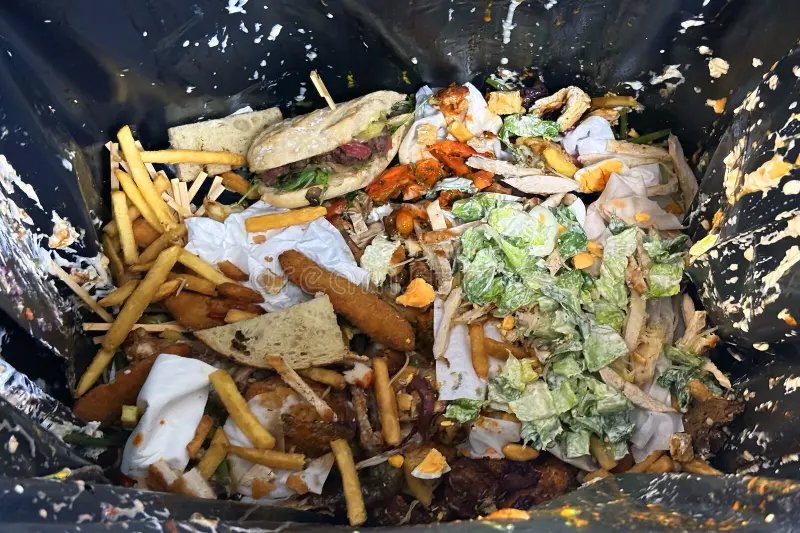

Text description: Waste behind restaurant.

--- Structured extraction ---
{
  "request_type": "complaint",
  "complaint_info": {
    "location": "behind restaurant",
    "waste_type": "food waste",
    "urgency": "MEDIUM",
    "department": "Environmental Services",
    "complaint_description": "Large amount of food waste visible in a trash bin behind a restaurant, including fries, salad, and sandwiches, as evidenced by the picture.",
    "accused_entity_type": "business"
  },
  "question_info": null,
  "resident_language": "English"
}


In [ ]:
from google.colab import files
from PIL import Image as PILImage # Added missing import

uploaded_image = None

try:
    uploaded = files.upload()
    for filename in uploaded.keys():
        image_path = filename
        uploaded_image = PILImage.open(image_path)
        print(f"Successfully uploaded: {filename}")

        # Optional: Ask for text description to accompany the image
        image_description = input("Enter a brief text description to go with your image (optional): ")

        print("--- Image Input (and optional text) ---")
        # Display the image if it's uploaded
        # In Colab, PIL.Image object will be displayed automatically
        display(uploaded_image)
        if image_description: print(f"Text description: {image_description}")

        print("\n--- Structured extraction ---")
        result_image = extract_structured(image_description, uploaded_image)
        print(json.dumps(result_image, indent=2, ensure_ascii=False))
        break # Process only one image for now
except Exception as e:
    print(f"An error occurred during file upload or processing: {e}")
    print("No image uploaded or an issue occurred.")

7: Transformed code, so that user can upload a picture and then only has the chance to input an optional description in words. AI uses user input as guidance, but formulates the official complaint_description itself by analyzing the picture.

In [ ]:
def analyze_image(image_path, question):
    """
    Send an image + a question to Gemini and return the response.
    Returns: (response_text, usage_metadata)
    """
    m = genai.GenerativeModel(model_name="gemini-2.5-flash")
    img = PILImage.open(image_path)
    response = m.generate_content([question, img])
    time.sleep(12)  # stays under free tier rate limit
    return response.text, response.usage_metadata

print("analyze_image() function defined. Ready to use in Parts 3 and 4.")

analyze_image() function defined. Ready to use in Parts 3 and 4.


8: Setup for core analysis.

In [ ]:
civic_questions = [
    ("PROBLEM",  "Describe the civic or environmental problem visible in this image. Be specific about what you see."),
    ("IMPACT",   "What are the public health, safety, or community impacts of what is shown in this image?"),
    ("URGENCY",  "Rate the urgency of this situation as LOW, MEDIUM, or HIGH. Explain your rating in 2–3 sentences."),
    ("ACTION",   "Which specific city department or service should respond to this? What action should they take?")
]

civic_results = {"answers": {}, "total_tokens": 0}

for label, question in civic_questions:
    print(f"--- {label} ---")
    answer, usage = analyze_image(image_path, question)
    civic_results["answers"][label] = answer
    civic_results["total_tokens"] += usage.total_token_count
    print(answer)
    print()

print(f"--- Total tokens used: {civic_results['total_tokens']} ---")
print("Running on Gemini free tier — no cost.")

--- PROBLEM ---
The image clearly depicts the significant problem of **food waste**.

Specifically, I see:
*   A large volume of discarded, uneaten food items collected in what appears to be a commercial or institutional trash bin, lined with a black plastic bag.
*   **Identifiable food items** include: a relatively intact beef or steak sandwich, a substantial portion of salad (likely Caesar salad due to the dressing and lettuce type), numerous French fries, pieces of bread, what appear to be fried chicken or fish pieces (like nuggets or fish fingers), and possibly hard-boiled egg fragments.
*   Much of the food appears to be freshly prepared and only partially consumed, or even entirely untouched, suggesting it was discarded shortly after preparation or purchase.
*   The bin itself and the liner show splatters and residue, indicating previous or ongoing disposal of similar food items.

This visible waste highlights several civic and environmental problems:

1.  **Environmental Impact 

9: Adjusted the core analysis code, so it matches the variable names I used. AI is properly analyzing the user input and breaks it down into the previously identified sections.

In [ ]:
custom_question = input("\nAsk your own question about the image: ")
custom_result, custom_usage = analyze_image(image_path, custom_question)

print("\n--- Response ---")
print(custom_result)
print(f"\nTokens used: {custom_usage.total_token_count}")


Ask your own question about the image: Is there any offical regulation that prohibits this behavior?

--- Response ---
While there isn't a universal official regulation that outright "prohibits" the generation of food waste in the sense of making it illegal to discard any uneaten food, many countries, regions, and cities have implemented a variety of official regulations and policies aimed at **reducing, preventing, or diverting food waste** from landfills.

The behavior shown in the image (discarding perfectly edible or once-edible food in a general waste bin) is specifically targeted by these regulations in various ways, especially when it comes to businesses like restaurants, supermarkets, or catering services.

Here's a breakdown of common types of regulations related to food waste:

1.  **Landfill Bans for Organic Waste:**
    *   **What it does:** Many jurisdictions prohibit or restrict organic materials, including food waste, from being sent to landfills.
    *   **Examples:** 

10: Came up with a new question that can further be build on with eg. "Where can I donate this food next time?"

# 4: Edge Case Elicitation

In [ ]:
print("--- Edge Case Elicitation ---")
edge_case_prompt = "Someone threw their food waste out on the street. It could be anyone."
print("Edge Case Prompt:\n" + edge_case_prompt)

edge_case_result = extract_structured(edge_case_prompt)
print("\n--- Structured Extraction for Edge Case ---")
print(json.dumps(edge_case_result, indent=2, ensure_ascii=False))


--- Edge Case Elicitation ---
Edge Case Prompt:
Someone threw their food waste out on the street. It could be anyone.

--- Structured Extraction for Edge Case ---
{
  "request_type": "complaint",
  "complaint_info": {
    "location": null,
    "waste_type": "food waste",
    "urgency": "MEDIUM",
    "department": "Environmental Services",
    "complaint_description": "Food waste was thrown out on the street. It is unclear who is responsible. Evidence type: text description.",
    "accused_entity_type": "unknown"
  },
  "question_info": null,
  "resident_language": "English"
}


Asked AI to help me build the framework to input an edge case prompt because I did not sure how to input it without changing my prior code. Then changed the prompt to my own made up one where the entity type was unknown. In this case the accused_entity_type is unknown and therefore a somewhat inoffical complaint would not lead to proper results. This is a near-miss because the evaluation is correct, there is just important information missing that the AI would have needed to reask about to get clarifications.